# Per-Label Collapse Analysis for AstroDINO Embeddings

This notebook performs per-label analysis of AstroDINO embeddings to understand:

1. **Intra-class structure**: How embeddings of the same label are distributed
2. **Inter-class vs Intra-class similarity**: Compare same-label vs different-label similarities
3. **Label-specific dimensions**: Which dimensions are informative for each label
4. **Per-label collapse detection**: Check if specific labels show collapse patterns

In [1]:
import os
import sys
import numpy as np
import torch
import h5py
from torch.utils.data import DataLoader
from omegaconf import OmegaConf
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns

# Add project root to path
PROJECT_ROOT = "/u/yacheng/projects/ssl_outthere"
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "encoder_image/astrodino/benchmark/linearprobe"))

from dinov2.eval.setup import build_model_for_eval
from dataset import JWSTMorphDataset

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [29]:
# Configuration
MODEL_CONFIG = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/config.yaml"
MODEL_WEIGHTS = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/eval/training_149999/teacher_checkpoint.pth"
DATA_ROOT = "/u/yacheng/projects/ssl_outthere/images/jwst/f150w"

# Morphology label names (morph_flag_f150w)
LABEL_NAMES = {
    0: 'Spheroid',
    1: 'Disk-dominated', 
    2: 'Irregular',
    3: 'Bulge-dominated',
}

BATCH_SIZE = 64
MAX_SAMPLES = -1  # Use all valid samples
BALANCED = True  # Don't balance for full distribution view
DELTA_THRESHOLD = 0.1

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda:0


## 1. Load Model and Dataset

In [30]:
# Load model
print('Loading model...')
cfg = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE)
model.eval()
print(f'Model loaded, crop_size={cfg.crops.global_crops_size}')

Loading model...
Model loaded, crop_size=64


In [35]:
# Create dataset
dataset = JWSTMorphDataset(
    DATA_ROOT,
    crop_size=cfg.crops.global_crops_size,
    max_samples=-1,
    balanced=False,
    delta_threshold=0.1
)
print(f'Dataset size: {len(dataset)}')

Loaded 20 files


Indexing valid samples: 100%|██████████| 20/20 [00:00<00:00, 423.24it/s]

Total valid samples (delta < 0.1): 11968
Label distribution:
  Class 0: 3021 samples (25.2%)
  Class 1: 2347 samples (19.6%)
  Class 2: 5505 samples (46.0%)
  Class 3: 1095 samples (9.1%)
Dataset size: 11968


In [36]:
# Compute embeddings
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

all_embeddings = []
all_labels = []

with torch.no_grad():
    for batch_imgs, batch_labels in tqdm(dataloader, desc='Computing embeddings'):
        batch_imgs = batch_imgs.to(DEVICE)
        emb = model(batch_imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        all_embeddings.append(emb.cpu().numpy())
        all_labels.append(batch_labels.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f'Embeddings shape: {embeddings.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Unique labels: {np.unique(labels)}')

Computing embeddings: 100%|██████████| 187/187 [00:16<00:00, 11.05it/s]

Embeddings shape: (11968, 768)
Labels shape: (11968,)
Unique labels: [0 1 2 3]


## 2. Helper Functions

In [37]:
def l2_normalize(embeddings):
    """L2 normalize embeddings along the feature dimension."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / (norms + 1e-8)


def compute_intra_inter_similarity(embeddings, labels, n_sample=1000, seed=42):
    """Compute intra-class and inter-class cosine similarities.
    
    Returns:
        intra_sims: dict mapping label -> array of intra-class similarities
        inter_sims: dict mapping (label1, label2) -> array of inter-class similarities
    """
    rng = np.random.default_rng(seed)
    unique_labels = np.unique(labels)
    
    intra_sims = {}
    inter_sims = {}
    
    # Group embeddings by label
    label_to_emb = {}
    for label in unique_labels:
        mask = labels == label
        label_to_emb[label] = embeddings[mask]
    
    # Compute intra-class similarities
    for label in unique_labels:
        emb = label_to_emb[label]
        n = min(n_sample, len(emb))
        if n < 2:
            continue
        idx = rng.choice(len(emb), size=n, replace=False)
        emb_sample = emb[idx]
        cos_sim = cosine_similarity(emb_sample)
        triu_idx = np.triu_indices(n, k=1)
        intra_sims[label] = cos_sim[triu_idx]
    
    # Compute inter-class similarities
    for i, label1 in enumerate(unique_labels):
        for label2 in unique_labels[i+1:]:
            emb1 = label_to_emb[label1]
            emb2 = label_to_emb[label2]
            n1 = min(n_sample // 2, len(emb1))
            n2 = min(n_sample // 2, len(emb2))
            if n1 < 1 or n2 < 1:
                continue
            idx1 = rng.choice(len(emb1), size=n1, replace=False)
            idx2 = rng.choice(len(emb2), size=n2, replace=False)
            cos_sim = cosine_similarity(emb1[idx1], emb2[idx2])
            inter_sims[(label1, label2)] = cos_sim.flatten()
    
    return intra_sims, inter_sims


def compute_per_label_nn_stats(embeddings, labels, k=10, n_sample=1000, seed=42):
    """Compute NN statistics per label: same-class vs different-class NN ratios.
    
    Returns:
        stats: dict with per-label NN statistics
    """
    rng = np.random.default_rng(seed)
    unique_labels = np.unique(labels)
    n_total = len(embeddings)
    
    # Sample for efficiency
    n_sample = min(n_sample, n_total)
    idx = rng.choice(n_total, size=n_sample, replace=False)
    emb_sample = embeddings[idx]
    labels_sample = labels[idx]
    
    # Fit NN on full embeddings, query with sample
    nn = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    nn.fit(embeddings)
    distances, indices = nn.kneighbors(emb_sample)
    
    stats = {}
    for label in unique_labels:
        label_mask = labels_sample == label
        if label_mask.sum() < 1:
            continue
        
        label_indices = np.where(label_mask)[0]
        same_class_ratio = []
        d1_list = []
        dk_list = []
        
        for i in label_indices:
            nn_indices = indices[i, 1:]  # Exclude self
            nn_labels = labels[nn_indices]
            same_class = (nn_labels == label).sum() / k
            same_class_ratio.append(same_class)
            d1_list.append(distances[i, 1])
            dk_list.append(distances[i, k])
        
        stats[label] = {
            'same_class_ratio': np.array(same_class_ratio),
            'd1': np.array(d1_list),
            'dk': np.array(dk_list),
            'nn_gap_ratio': (np.array(dk_list) - np.array(d1_list)) / (np.array(d1_list) + 1e-8)
        }
    
    return stats


def compute_per_label_variance(embeddings, labels):
    """Compute per-dimension variance for each label.
    
    Returns:
        variances: dict mapping label -> per-dimension variance array
    """
    unique_labels = np.unique(labels)
    variances = {}
    
    for label in unique_labels:
        mask = labels == label
        emb = embeddings[mask]
        if len(emb) < 2:
            continue
        emb_centered = emb - emb.mean(axis=0)
        variances[label] = np.var(emb_centered, axis=0)
    
    return variances


def compute_label_discriminative_dims(embeddings, labels, top_k=50):
    """Find dimensions most discriminative for each label using Fisher's criterion.
    
    Fisher score = (between-class variance) / (within-class variance)
    
    Returns:
        fisher_scores: array of shape (n_dims,) with Fisher scores per dimension
        label_top_dims: dict mapping label -> most important dims for that label
    """
    unique_labels = np.unique(labels)
    n_dims = embeddings.shape[1]
    
    # Global mean
    global_mean = embeddings.mean(axis=0)
    
    # Compute class means and within-class variance
    class_means = {}
    class_vars = {}
    class_counts = {}
    
    for label in unique_labels:
        mask = labels == label
        emb = embeddings[mask]
        class_means[label] = emb.mean(axis=0)
        class_vars[label] = emb.var(axis=0)
        class_counts[label] = len(emb)
    
    # Between-class variance
    between_var = np.zeros(n_dims)
    for label in unique_labels:
        between_var += class_counts[label] * (class_means[label] - global_mean) ** 2
    between_var /= len(embeddings)
    
    # Within-class variance (pooled)
    within_var = np.zeros(n_dims)
    for label in unique_labels:
        within_var += class_counts[label] * class_vars[label]
    within_var /= len(embeddings)
    
    # Fisher score
    fisher_scores = between_var / (within_var + 1e-8)
    
    # For each label, find dims where class mean deviates most from global mean
    label_top_dims = {}
    for label in unique_labels:
        diff = np.abs(class_means[label] - global_mean)
        top_dims = np.argsort(diff)[::-1][:top_k]
        label_top_dims[label] = top_dims
    
    return fisher_scores, label_top_dims, class_means

## 3. L2 Normalize Embeddings

In [38]:
# Check if already normalized
norms = np.linalg.norm(embeddings, axis=1)
print(f'Original norms - mean: {norms.mean():.3f}, std: {norms.std():.3f}')

# L2 normalize
embeddings_norm = l2_normalize(embeddings)
norms_after = np.linalg.norm(embeddings_norm, axis=1)
print(f'After normalization - mean: {norms_after.mean():.3f}, std: {norms_after.std():.3f}')

Original norms - mean: 28.604, std: 0.120
After normalization - mean: 1.000, std: 0.000


## 4. Intra-class vs Inter-class Similarity Analysis

In [39]:
# Compute intra and inter class similarities
intra_sims, inter_sims = compute_intra_inter_similarity(embeddings_norm, labels, n_sample=2000)

# Print summary statistics
print('=' * 70)
print('Intra-class Cosine Similarity (same label)')
print('=' * 70)
for label in sorted(intra_sims.keys()):
    sims = intra_sims[label]
    name = LABEL_NAMES.get(label, f'Class {label}')
    print(f'{name:15s}: mean={sims.mean():.4f}, std={sims.std():.4f}, '
          f'min={sims.min():.4f}, max={sims.max():.4f}')

print('\n' + '=' * 70)
print('Inter-class Cosine Similarity (different labels)')
print('=' * 70)
for (l1, l2), sims in sorted(inter_sims.items()):
    name1 = LABEL_NAMES.get(l1, f'Class {l1}')
    name2 = LABEL_NAMES.get(l2, f'Class {l2}')
    print(f'{name1:12s} vs {name2:12s}: mean={sims.mean():.4f}, std={sims.std():.4f}')

Intra-class Cosine Similarity (same label)
Spheroid       : mean=0.2449, std=0.2037, min=-0.2189, max=0.9969
Disk-dominated : mean=0.1700, std=0.1897, min=-0.2249, max=0.9997
Irregular      : mean=0.1648, std=0.1839, min=-0.2501, max=0.9933
Bulge-dominated: mean=0.2548, std=0.2451, min=-0.1906, max=0.9990

Inter-class Cosine Similarity (different labels)
Spheroid     vs Disk-dominated: mean=0.1097, std=0.1553
Spheroid     vs Irregular   : mean=0.1830, std=0.1943
Spheroid     vs Bulge-dominated: mean=0.1628, std=0.1962
Disk-dominated vs Irregular   : mean=0.1345, std=0.1718
Disk-dominated vs Bulge-dominated: mean=0.1633, std=0.1999
Irregular    vs Bulge-dominated: mean=0.1614, std=0.1955


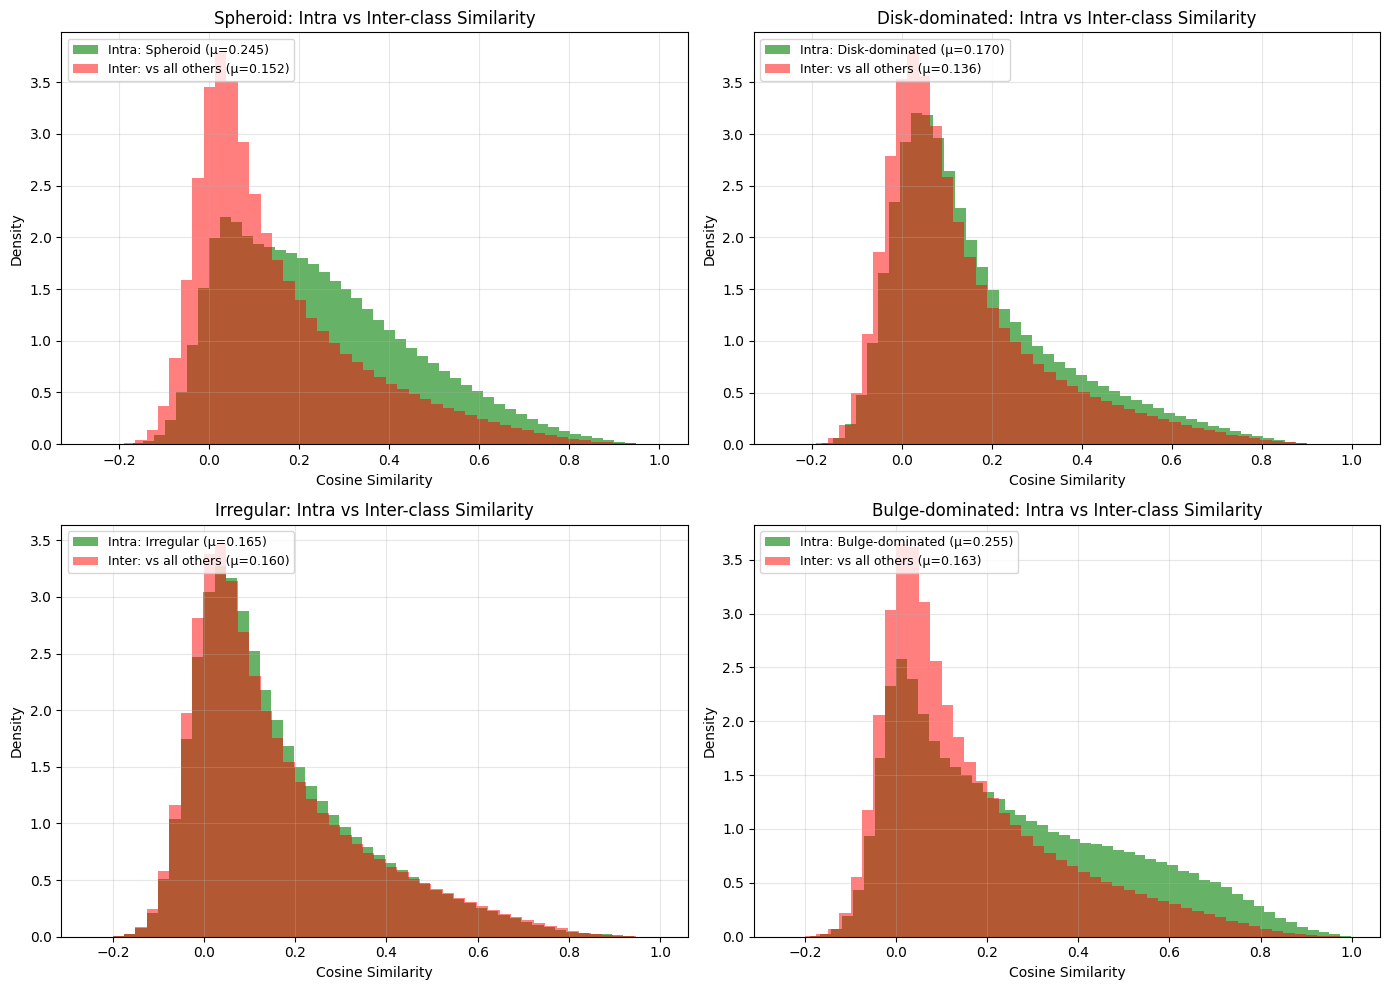

In [40]:
# Plot per-label: intra-class vs inter-class (combined) similarity distributions
n_labels = len(intra_sims)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, label in enumerate(sorted(intra_sims.keys())):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    name = LABEL_NAMES.get(label, f'Class {label}')
    
    # Plot intra-class similarity
    ax.hist(intra_sims[label], bins=50, alpha=0.6, density=True, 
            color='green', label=f'Intra: {name} (μ={intra_sims[label].mean():.3f})')
    
    # Combine all inter-class similarities for this label
    inter_combined = []
    for (l1, l2), sims in inter_sims.items():
        if l1 == label or l2 == label:
            inter_combined.append(sims)
    
    if inter_combined:
        inter_combined = np.concatenate(inter_combined)
        ax.hist(inter_combined, bins=50, alpha=0.5, density=True,
                color='red', label=f'Inter: vs all others (μ={inter_combined.mean():.3f})')
    
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}: Intra vs Inter-class Similarity')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(len(intra_sims), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Per-Label NN Analysis

In [41]:
# Compute per-label NN statistics
nn_stats = compute_per_label_nn_stats(embeddings_norm, labels, k=10, n_sample=2000)

print('=' * 70)
print('Per-Label NN Statistics (k=10)')
print('=' * 70)
print(f'{"Label":15s} {"Same-class ratio":>18s} {"d_1 mean":>12s} {"NN Gap Ratio":>14s}')
print('-' * 70)
for label in sorted(nn_stats.keys()):
    stats = nn_stats[label]
    name = LABEL_NAMES.get(label, f'Class {label}')
    same_ratio = stats['same_class_ratio'].mean()
    d1_mean = stats['d1'].mean()
    gap_ratio = stats['nn_gap_ratio'].mean()
    print(f'{name:15s} {same_ratio:>18.1%} {d1_mean:>12.4f} {gap_ratio:>14.4f}')

Per-Label NN Statistics (k=10)
Label             Same-class ratio     d_1 mean   NN Gap Ratio
----------------------------------------------------------------------
Spheroid                     47.5%       0.5184         0.2189
Disk-dominated               39.4%       0.4963         0.2768
Irregular                    47.1%       0.5252         0.2341
Bulge-dominated              30.3%       0.3881         0.4689


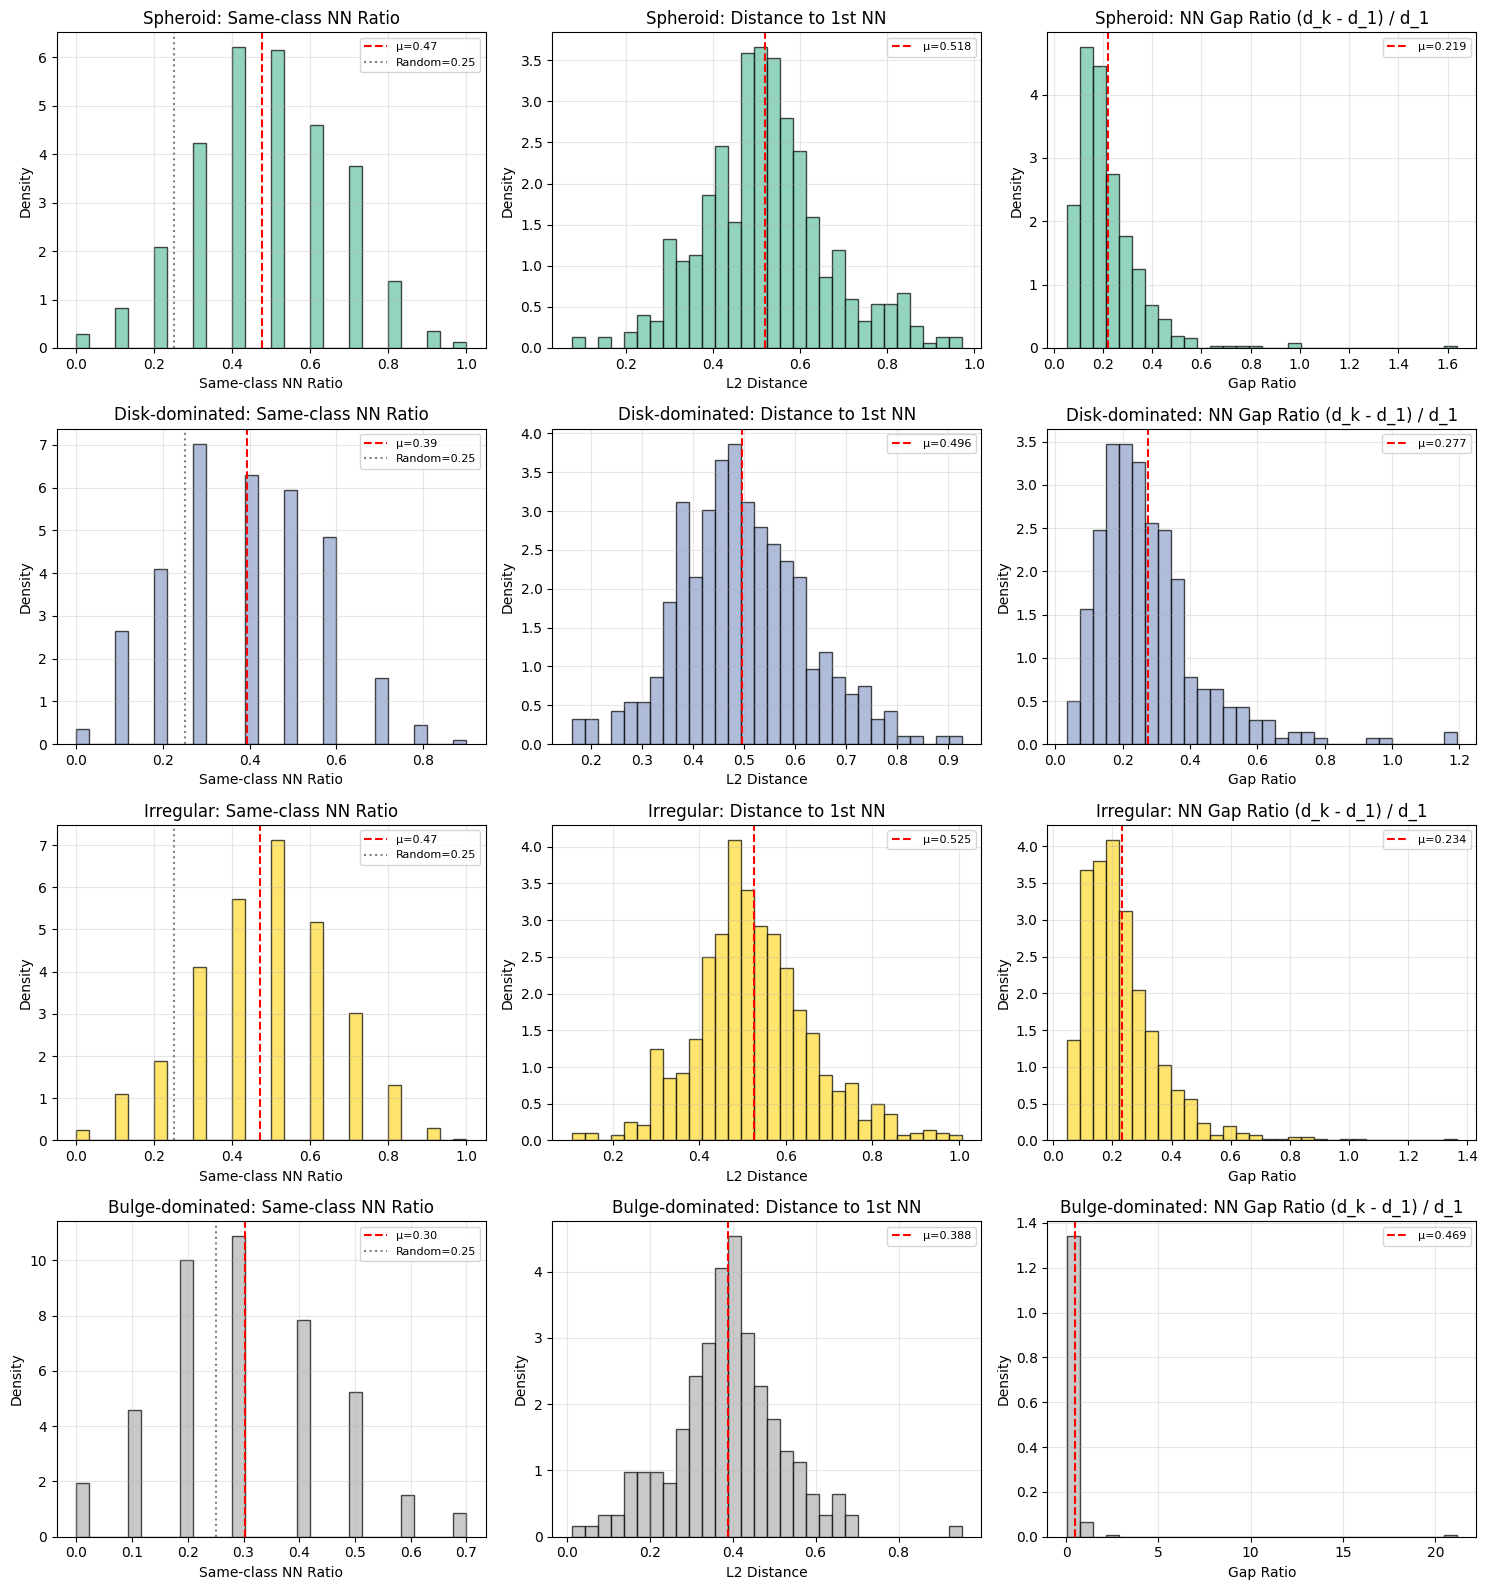

In [42]:
# Plot per-label NN statistics as distribution subplots
n_labels = len(nn_stats)
fig, axes = plt.subplots(n_labels, 3, figsize=(15, 4 * n_labels))

label_names_list = [LABEL_NAMES.get(l, f'Class {l}') for l in sorted(nn_stats.keys())]
colors = plt.cm.Set2(np.linspace(0, 1, n_labels))

for idx, label in enumerate(sorted(nn_stats.keys())):
    name = LABEL_NAMES.get(label, f'Class {label}')
    stats = nn_stats[label]
    color = colors[idx]
    
    # Same-class ratio distribution
    ax = axes[idx, 0]
    ax.hist(stats['same_class_ratio'], bins=30, alpha=0.7, color=color, density=True, edgecolor='black')
    ax.axvline(x=stats['same_class_ratio'].mean(), color='red', linestyle='--', 
               label=f'μ={stats["same_class_ratio"].mean():.2f}')
    ax.axvline(x=1/n_labels, color='gray', linestyle=':', label=f'Random={1/n_labels:.2f}')
    ax.set_xlabel('Same-class NN Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}: Same-class NN Ratio')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # d1 distance distribution
    ax = axes[idx, 1]
    ax.hist(stats['d1'], bins=30, alpha=0.7, color=color, density=True, edgecolor='black')
    ax.axvline(x=stats['d1'].mean(), color='red', linestyle='--', 
               label=f'μ={stats["d1"].mean():.3f}')
    ax.set_xlabel('L2 Distance')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}: Distance to 1st NN')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # NN gap ratio distribution
    ax = axes[idx, 2]
    ax.hist(stats['nn_gap_ratio'], bins=30, alpha=0.7, color=color, density=True, edgecolor='black')
    ax.axvline(x=stats['nn_gap_ratio'].mean(), color='red', linestyle='--', 
               label=f'μ={stats["nn_gap_ratio"].mean():.3f}')
    ax.set_xlabel('Gap Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}: NN Gap Ratio (d_k - d_1) / d_1')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Per-Label Dimension Variance Analysis

In [43]:
# Compute per-label variance
label_variances = compute_per_label_variance(embeddings_norm, labels)

# Overall variance
overall_variance = np.var(embeddings_norm - embeddings_norm.mean(axis=0), axis=0)

# Summary
print('=' * 70)
print('Per-Label Dimension Variance')
print('=' * 70)
n_dims = embeddings_norm.shape[1]
expected_var = 1.0 / n_dims
print(f'Expected variance (isotropic): {expected_var:.6f}')
print(f'\nOverall variance - mean: {overall_variance.mean():.6f}, std: {overall_variance.std():.6f}')
print(f'  Dead dims (var < {expected_var*0.01:.2e}): {(overall_variance < expected_var*0.01).sum()} / {n_dims}')

print('\nPer-label:')
for label in sorted(label_variances.keys()):
    var = label_variances[label]
    name = LABEL_NAMES.get(label, f'Class {label}')
    dead = (var < expected_var * 0.01).sum()
    print(f'  {name:15s}: mean={var.mean():.6f}, std={var.std():.6f}, dead_dims={dead}')

Per-Label Dimension Variance
Expected variance (isotropic): 0.001302

Overall variance - mean: 0.001089, std: 0.000784
  Dead dims (var < 1.30e-05): 0 / 768

Per-label:
  Spheroid       : mean=0.000982, std=0.000749, dead_dims=0
  Disk-dominated : mean=0.001081, std=0.000801, dead_dims=0
  Irregular      : mean=0.001090, std=0.000780, dead_dims=0
  Bulge-dominated: mean=0.000969, std=0.000870, dead_dims=0


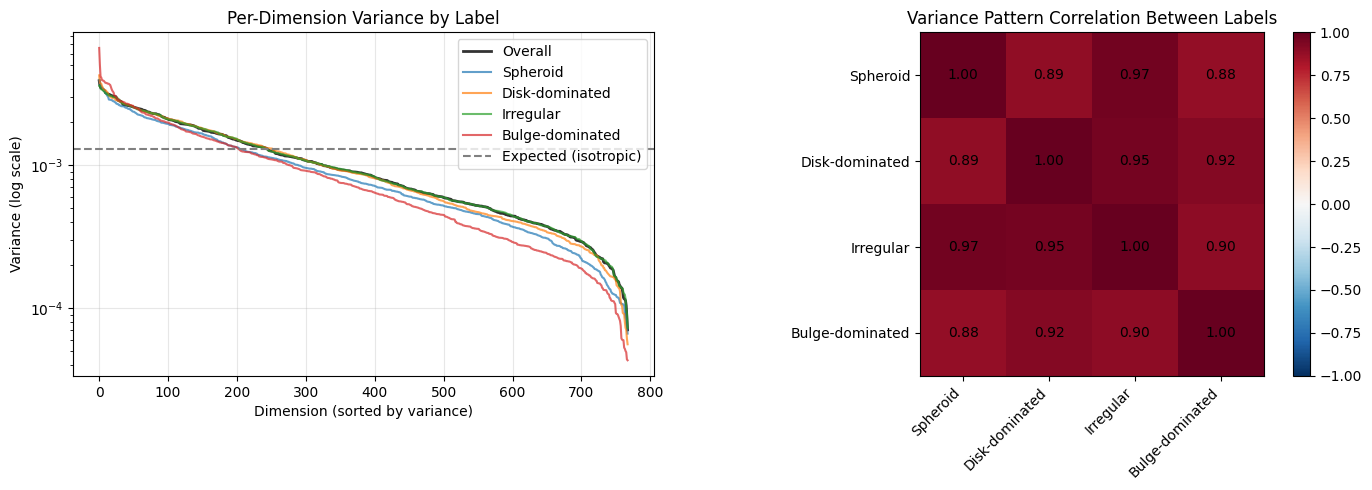

In [44]:
# Plot per-label variance spectra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sorted variance for each label
ax = axes[0]
ax.semilogy(np.sort(overall_variance)[::-1], 'k-', linewidth=2, label='Overall', alpha=0.8)
for label in sorted(label_variances.keys()):
    var = label_variances[label]
    name = LABEL_NAMES.get(label, f'Class {label}')
    ax.semilogy(np.sort(var)[::-1], linewidth=1.5, alpha=0.7, label=name)
ax.axhline(y=expected_var, color='gray', linestyle='--', label='Expected (isotropic)')
ax.set_xlabel('Dimension (sorted by variance)')
ax.set_ylabel('Variance (log scale)')
ax.set_title('Per-Dimension Variance by Label')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Variance correlation between labels
ax = axes[1]
label_list = sorted(label_variances.keys())
var_matrix = np.array([label_variances[l] for l in label_list])
corr_matrix = np.corrcoef(var_matrix)
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(label_list)))
ax.set_yticks(range(len(label_list)))
ax.set_xticklabels([LABEL_NAMES.get(l, str(l)) for l in label_list], rotation=45, ha='right')
ax.set_yticklabels([LABEL_NAMES.get(l, str(l)) for l in label_list])
ax.set_title('Variance Pattern Correlation Between Labels')
plt.colorbar(im, ax=ax)
for i in range(len(label_list)):
    for j in range(len(label_list)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Label-Discriminative Dimensions

In [45]:
# Compute Fisher scores and label-specific dimensions
fisher_scores, label_top_dims, class_means = compute_label_discriminative_dims(
    embeddings_norm, labels, top_k=50
)

print('=' * 70)
print('Fisher Score Analysis (higher = more discriminative)')
print('=' * 70)
print(f'Fisher score - mean: {fisher_scores.mean():.4f}, max: {fisher_scores.max():.4f}')
print(f'Top 10 discriminative dims: {np.argsort(fisher_scores)[::-1][:10]}')
print(f'Dims with Fisher > 1: {(fisher_scores > 1).sum()} / {len(fisher_scores)}')

# Check overlaps in top dimensions
print('\nTop 20 dimensions per label (most deviation from global mean):')
for label in sorted(label_top_dims.keys()):
    name = LABEL_NAMES.get(label, f'Class {label}')
    dims = label_top_dims[label][:20]
    print(f'  {name}: {list(dims)}')

Fisher Score Analysis (higher = more discriminative)
Fisher score - mean: 0.0469, max: 0.3120
Top 10 discriminative dims: [527 578 497  62 262  69 588 621 157 507]
Dims with Fisher > 1: 0 / 768

Top 20 dimensions per label (most deviation from global mean):
  Spheroid: [723, 682, 67, 62, 497, 693, 236, 181, 463, 396, 583, 180, 262, 644, 467, 670, 673, 659, 47, 466]
  Disk-dominated: [723, 67, 236, 682, 62, 497, 237, 466, 693, 262, 396, 180, 759, 583, 181, 659, 644, 129, 79, 463]
  Irregular: [62, 463, 181, 111, 291, 72, 345, 628, 255, 378, 615, 765, 232, 118, 381, 243, 39, 750, 466, 263]
  Bulge-dominated: [62, 463, 181, 709, 670, 689, 345, 628, 111, 39, 615, 446, 451, 33, 318, 161, 232, 663, 378, 291]


In [46]:
# Analyze top dimension overlap between labels
print('=' * 70)
print('TOP DIMENSION OVERLAP ANALYSIS')
print('=' * 70)

# Check pairwise overlap
label_list = sorted(label_top_dims.keys())
top_k_values = [10, 20, 50,100]

for top_k in top_k_values:
    print(f'\n--- Top-{top_k} Dimension Overlap ---')
    for i, l1 in enumerate(label_list):
        for l2 in label_list[i+1:]:
            name1 = LABEL_NAMES.get(l1, f'Class {l1}')
            name2 = LABEL_NAMES.get(l2, f'Class {l2}')
            dims1 = set(label_top_dims[l1][:top_k])
            dims2 = set(label_top_dims[l2][:top_k])
            overlap = dims1 & dims2
            overlap_ratio = len(overlap) / top_k
            print(f'{name1:15s} vs {name2:15s}: {len(overlap):3d}/{top_k} ({overlap_ratio:.1%})')

# Find shared dimensions across all labels
print('\n--- Dimensions Shared Across All Labels (Top-50) ---')
all_top_dims = [set(label_top_dims[l][:50]) for l in label_list]
shared_all = all_top_dims[0]
for dims in all_top_dims[1:]:
    shared_all = shared_all & dims
print(f'Dimensions in top-50 for ALL labels: {len(shared_all)}')
if len(shared_all) > 0:
    print(f'Shared dims: {sorted(shared_all)[:20]}...' if len(shared_all) > 20 else f'Shared dims: {sorted(shared_all)}')

# Find unique dimensions for each label
print('\n--- Unique Top Dimensions per Label (Top-50) ---')
for label in label_list:
    name = LABEL_NAMES.get(label, f'Class {label}')
    dims = set(label_top_dims[label][:50])
    other_dims = set()
    for other_label in label_list:
        if other_label != label:
            other_dims |= set(label_top_dims[other_label][:50])
    unique = dims - other_dims
    print(f'{name:15s}: {len(unique):3d} unique dims in top-50')

TOP DIMENSION OVERLAP ANALYSIS

--- Top-10 Dimension Overlap ---
Spheroid        vs Disk-dominated :   7/10 (70.0%)
Spheroid        vs Irregular      :   3/10 (30.0%)
Spheroid        vs Bulge-dominated:   3/10 (30.0%)
Disk-dominated  vs Irregular      :   1/10 (10.0%)
Disk-dominated  vs Bulge-dominated:   1/10 (10.0%)
Irregular       vs Bulge-dominated:   6/10 (60.0%)

--- Top-20 Dimension Overlap ---
Spheroid        vs Disk-dominated :  16/20 (80.0%)
Spheroid        vs Irregular      :   4/20 (20.0%)
Spheroid        vs Bulge-dominated:   4/20 (20.0%)
Disk-dominated  vs Irregular      :   4/20 (20.0%)
Disk-dominated  vs Bulge-dominated:   3/20 (15.0%)
Irregular       vs Bulge-dominated:  11/20 (55.0%)

--- Top-50 Dimension Overlap ---
Spheroid        vs Disk-dominated :  44/50 (88.0%)
Spheroid        vs Irregular      :   9/50 (18.0%)
Spheroid        vs Bulge-dominated:  14/50 (28.0%)
Disk-dominated  vs Irregular      :  10/50 (20.0%)
Disk-dominated  vs Bulge-dominated:  12/50 (24.0%)


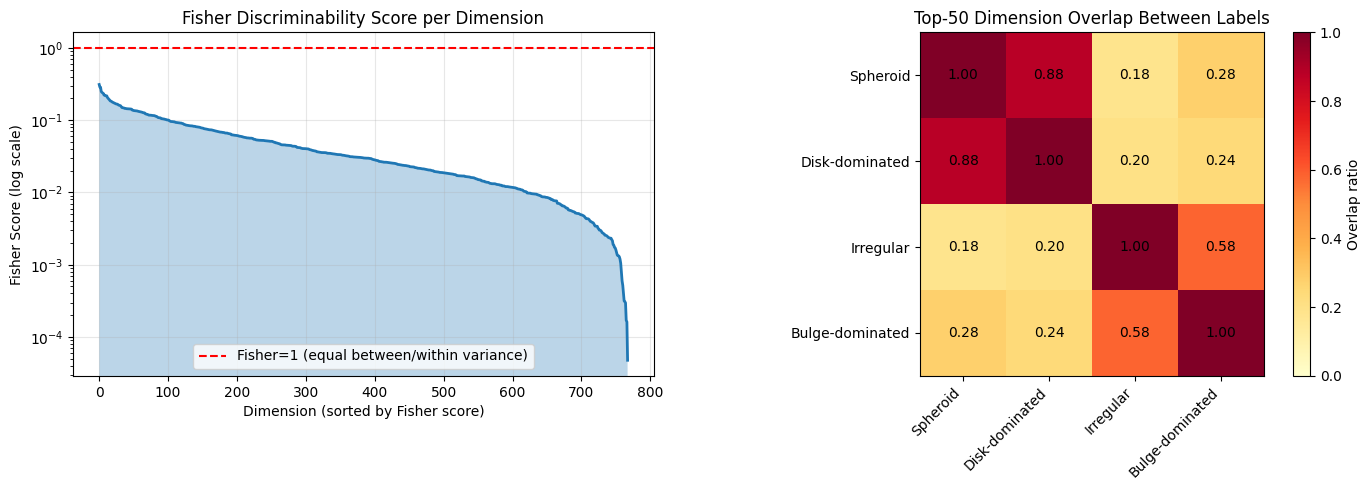

In [47]:
# Plot Fisher scores and dimension overlap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fisher score distribution
ax = axes[0]
sorted_fisher = np.sort(fisher_scores)[::-1]
ax.semilogy(sorted_fisher, linewidth=2)
ax.axhline(y=1, color='r', linestyle='--', label='Fisher=1 (equal between/within variance)')
ax.fill_between(range(len(sorted_fisher)), sorted_fisher, alpha=0.3)
ax.set_xlabel('Dimension (sorted by Fisher score)')
ax.set_ylabel('Fisher Score (log scale)')
ax.set_title('Fisher Discriminability Score per Dimension')
ax.legend()
ax.grid(True, alpha=0.3)

# Dimension overlap heatmap
ax = axes[1]
label_list = sorted(label_top_dims.keys())
n_labels = len(label_list)
overlap_matrix = np.zeros((n_labels, n_labels))
top_k = 50  # Check overlap in top 50 dims

for i, l1 in enumerate(label_list):
    for j, l2 in enumerate(label_list):
        dims1 = set(label_top_dims[l1][:top_k])
        dims2 = set(label_top_dims[l2][:top_k])
        overlap = len(dims1 & dims2) / top_k
        overlap_matrix[i, j] = overlap

im = ax.imshow(overlap_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n_labels))
ax.set_yticks(range(n_labels))
ax.set_xticklabels([LABEL_NAMES.get(l, str(l)) for l in label_list], rotation=45, ha='right')
ax.set_yticklabels([LABEL_NAMES.get(l, str(l)) for l in label_list])
ax.set_title(f'Top-{top_k} Dimension Overlap Between Labels')
plt.colorbar(im, ax=ax, label='Overlap ratio')
for i in range(n_labels):
    for j in range(n_labels):
        ax.text(j, i, f'{overlap_matrix[i, j]:.2f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Per-Label Collapse Diagnosis

In [48]:
def per_label_collapse_analysis(embeddings, labels, label_names=None):
    """Comprehensive per-label collapse analysis."""
    unique_labels = np.unique(labels)
    n_dims = embeddings.shape[1]
    expected_var = 1.0 / n_dims
    
    results = {}
    
    for label in unique_labels:
        mask = labels == label
        emb = embeddings[mask]
        n_samples = len(emb)
        
        if n_samples < 10:
            continue
        
        name = label_names.get(label, f'Class {label}') if label_names else f'Class {label}'
        
        # Intra-class cosine similarity
        n_sample = min(500, n_samples)
        idx = np.random.choice(n_samples, size=n_sample, replace=False)
        cos_sim = cosine_similarity(emb[idx])
        cos_vals = cos_sim[np.triu_indices(n_sample, k=1)]
        cos_mean = cos_vals.mean()
        cos_std = cos_vals.std()
        
        # Per-dimension variance
        emb_centered = emb - emb.mean(axis=0)
        dim_variance = np.var(emb_centered, axis=0)
        dead_dims = (dim_variance < expected_var * 0.01).sum()
        
        # Effective dimensionality
        cov_matrix = np.cov(emb.T)
        eigenvalues = np.linalg.eigvalsh(cov_matrix)
        eigenvalues = np.sort(eigenvalues)[::-1]
        eigenvalues = np.maximum(eigenvalues, 1e-12)
        normalized_eig = eigenvalues / eigenvalues.sum()
        participation_ratio = 1.0 / np.sum(normalized_eig ** 2)
        entropy = -np.sum(normalized_eig * np.log(normalized_eig + 1e-12))
        effective_rank = np.exp(entropy)
        
        # Collapse signals
        collapse_signals = {
            'eff_rank_low': effective_rank / n_dims < 0.05,
            'dead_dims_high': dead_dims / n_dims > 0.5,
            'cos_sim_concentrated': (cos_mean > 0.8) and (cos_std < 0.1),
        }
        n_signals = sum(collapse_signals.values())
        
        results[label] = {
            'name': name,
            'n_samples': n_samples,
            'cos_mean': cos_mean,
            'cos_std': cos_std,
            'dead_dims': dead_dims,
            'participation_ratio': participation_ratio,
            'effective_rank': effective_rank,
            'eigenvalues': eigenvalues,
            'collapse_signals': n_signals,
            'collapse_details': collapse_signals
        }
    
    return results

In [49]:
# Run per-label collapse analysis
collapse_results = per_label_collapse_analysis(embeddings_norm, labels, LABEL_NAMES)

# Print results
print('=' * 90)
print('PER-LABEL COLLAPSE ANALYSIS')
print('=' * 90)
print(f'{"Label":15s} {"N":>8s} {"Cos_μ":>8s} {"Cos_σ":>8s} {"Dead":>8s} {"Eff.Rank":>10s} {"Signals":>8s}')
print('-' * 90)

for label in sorted(collapse_results.keys()):
    r = collapse_results[label]
    status = '⚠️' if r['collapse_signals'] >= 2 else '✓'
    print(f'{r["name"]:15s} {r["n_samples"]:>8d} {r["cos_mean"]:>8.4f} {r["cos_std"]:>8.4f} '
          f'{r["dead_dims"]:>8d} {r["effective_rank"]:>10.1f} {r["collapse_signals"]:>7d}/3 {status}')

print('\n' + '=' * 90)
print('COLLAPSE SIGNAL DETAILS')
print('=' * 90)
for label in sorted(collapse_results.keys()):
    r = collapse_results[label]
    details = r['collapse_details']
    print(f'\n{r["name"]}:')
    for signal, triggered in details.items():
        status = '⚠️ YES' if triggered else '✓ NO'
        print(f'  {signal:25s}: {status}')

PER-LABEL COLLAPSE ANALYSIS
Label                  N    Cos_μ    Cos_σ     Dead   Eff.Rank  Signals
------------------------------------------------------------------------------------------
Spheroid            3021   0.2436   0.2077        0       47.2       0/3 ✓
Disk-dominated      2347   0.1696   0.1891        0       50.6       0/3 ✓
Irregular           5505   0.1576   0.1804        0       62.4       0/3 ✓
Bulge-dominated     1095   0.2554   0.2434        0       27.5       1/3 ✓

COLLAPSE SIGNAL DETAILS

Spheroid:
  eff_rank_low             : ✓ NO
  dead_dims_high           : ✓ NO
  cos_sim_concentrated     : ✓ NO

Disk-dominated:
  eff_rank_low             : ✓ NO
  dead_dims_high           : ✓ NO
  cos_sim_concentrated     : ✓ NO

Irregular:
  eff_rank_low             : ✓ NO
  dead_dims_high           : ✓ NO
  cos_sim_concentrated     : ✓ NO

Bulge-dominated:
  eff_rank_low             : ⚠️ YES
  dead_dims_high           : ✓ NO
  cos_sim_concentrated     : ✓ NO


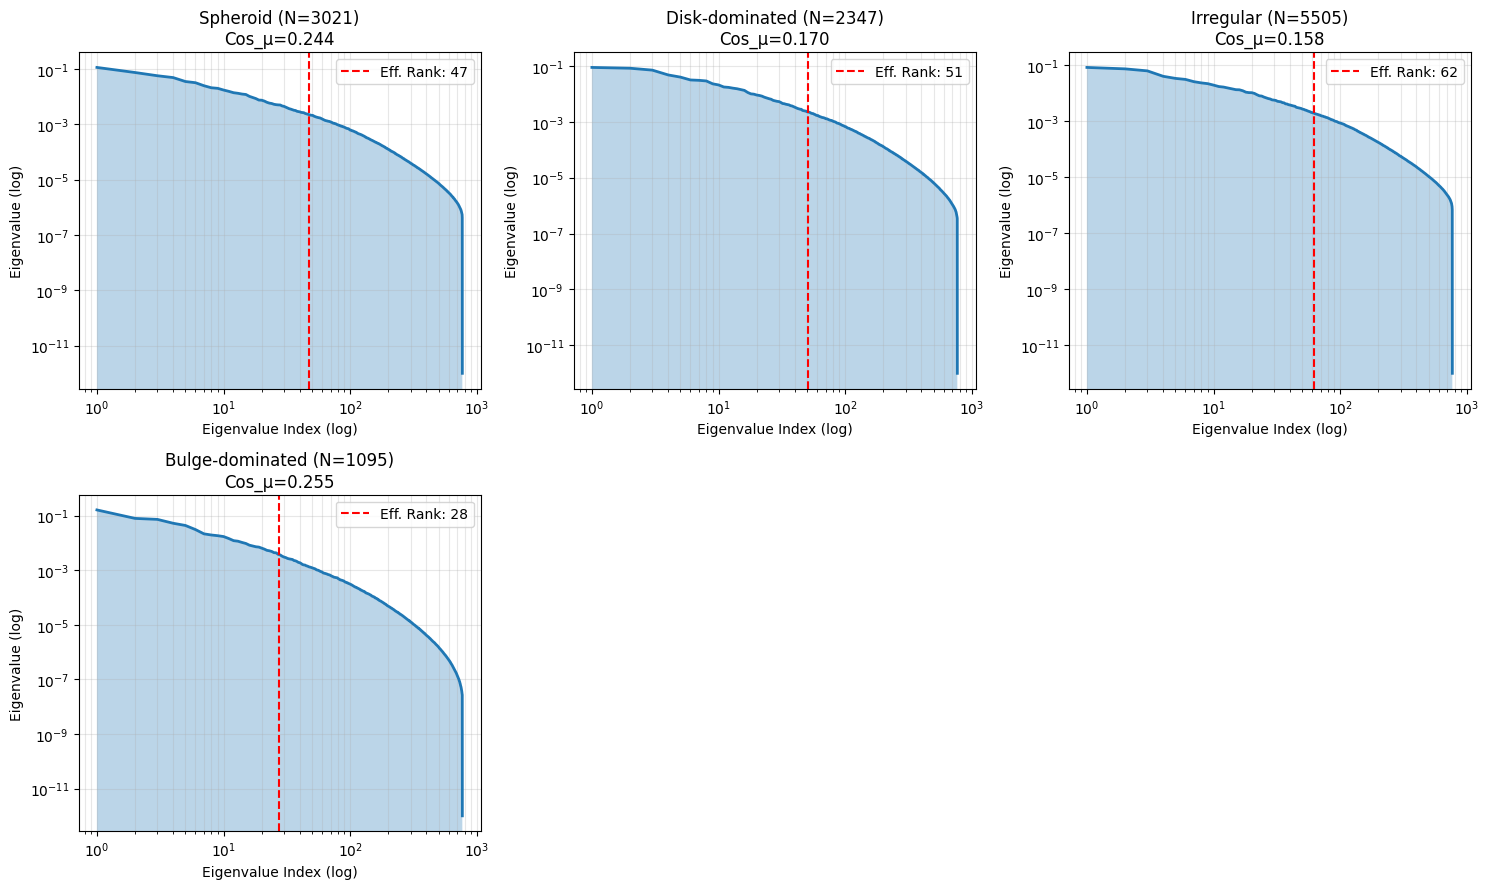

In [50]:
# Plot per-label eigenvalue spectra
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, label in enumerate(sorted(collapse_results.keys())):
    if idx >= len(axes):
        break
    
    r = collapse_results[label]
    ax = axes[idx]
    
    eigenvalues = r['eigenvalues']
    eig_indices = np.arange(1, len(eigenvalues) + 1)
    
    ax.loglog(eig_indices, eigenvalues, linewidth=2)
    ax.axvline(x=r['effective_rank'], color='r', linestyle='--', 
               label=f'Eff. Rank: {r["effective_rank"]:.0f}')
    ax.fill_between(eig_indices, eigenvalues, alpha=0.3)
    
    ax.set_xlabel('Eigenvalue Index (log)')
    ax.set_ylabel('Eigenvalue (log)')
    ax.set_title(f'{r["name"]} (N={r["n_samples"]})\nCos_μ={r["cos_mean"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

# Hide unused axes
for idx in range(len(collapse_results), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Embedding Visualization (t-SNE / PCA)

In [51]:
# Subsample for visualization
n_vis = min(5000, len(embeddings_norm))
vis_idx = np.random.choice(len(embeddings_norm), size=n_vis, replace=False)
emb_vis = embeddings_norm[vis_idx]
labels_vis = labels[vis_idx]

print(f'Visualization samples: {n_vis}')

Visualization samples: 5000


In [52]:
# PCA
print('Running PCA...')
pca = PCA(n_components=50)
emb_pca = pca.fit_transform(emb_vis)
print(f'Explained variance (top 50): {pca.explained_variance_ratio_.sum():.2%}')

Running PCA...
Explained variance (top 50): 84.78%


In [53]:
# t-SNE
print('Running t-SNE (this may take a few minutes)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, verbose=1)
emb_tsne = tsne.fit_transform(emb_pca)  # Use PCA-reduced for speed

Running t-SNE (this may take a few minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.139s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.232334
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.414391
[t-SNE] KL divergence after 1000 iterations: 1.559045


In [54]:
# UMAP
print('Running UMAP...')
import umap
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42, verbose=True)
emb_umap = reducer.fit_transform(emb_pca)  # Use PCA-reduced for speed
print('UMAP done.')

Running UMAP...
UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Feb 19 00:13:48 2026 Construct fuzzy simplicial set
Thu Feb 19 00:13:48 2026 Finding Nearest Neighbors
Thu Feb 19 00:13:48 2026 Building RP forest with 9 trees


/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Feb 19 00:13:53 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Thu Feb 19 00:14:00 2026 Finished Nearest Neighbor Search
Thu Feb 19 00:14:00 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Feb 19 00:14:06 2026 Finished embedding
UMAP done.


Text(0.5, 1.0, 'UMAP Visualization')

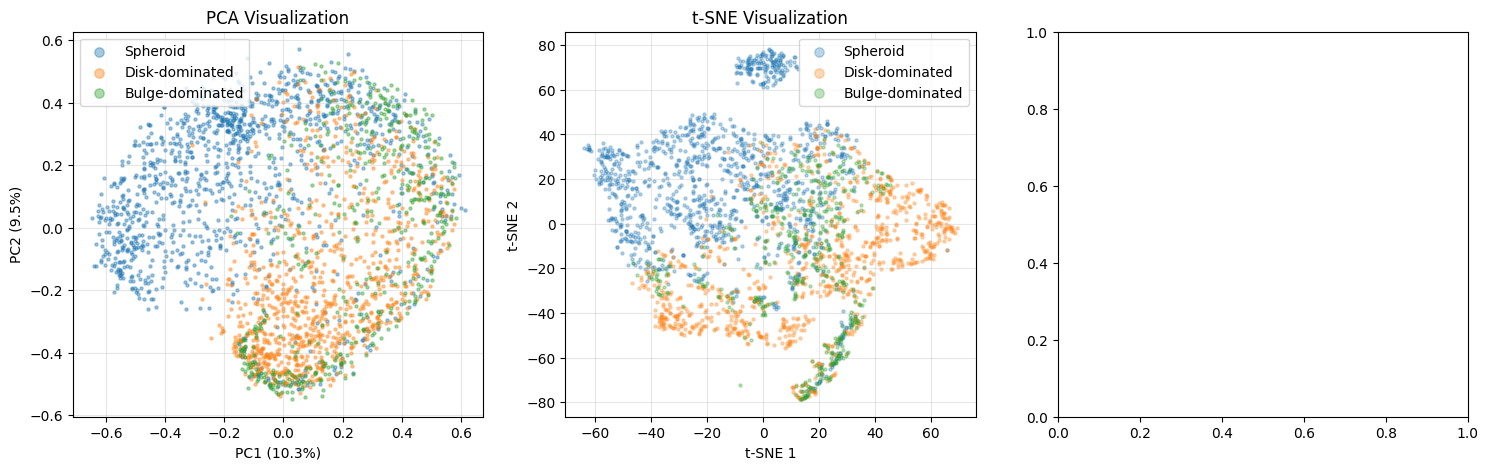

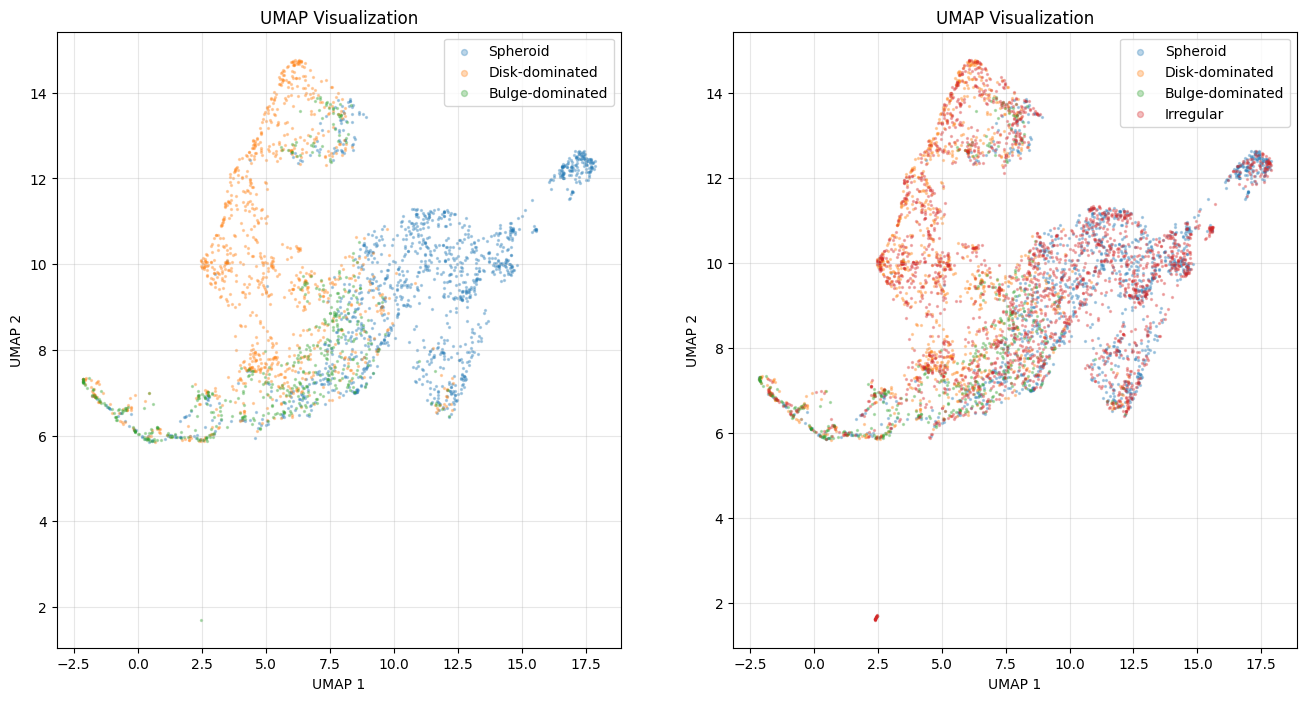

In [56]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
ax = axes[0]
for label in np.unique(labels_vis):
    if label == 2:
        continue
    mask = labels_vis == label
    name = LABEL_NAMES.get(label, f'Class {label}')
    ax.scatter(emb_pca[mask, 0], emb_pca[mask, 1], s=5, alpha=0.4, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA Visualization')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)

# t-SNE
ax = axes[1]
for label in np.unique(labels_vis):
    if label == 2:
        continue
    mask = labels_vis == label
    name = LABEL_NAMES.get(label, f'Class {label}')
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], s=5, alpha=0.3, label=name)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE Visualization')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)

# UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax = axes[0]

for label in np.unique(labels_vis):
    if label == 2:
        continue
    mask = labels_vis == label

    name = LABEL_NAMES.get(label, f'Class {label}')

    ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1], s=2, alpha=0.3, label=name)
ax.grid(True, alpha=0.3)

ax.set_xlabel('UMAP 1')
ax.legend(markerscale=3)
#ax.set_ylim(-4,)
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Visualization')

ax = axes[1]

for label in np.unique(labels_vis):
    if label == 2:
        continue
    mask = labels_vis == label

    name = LABEL_NAMES.get(label, f'Class {label}')

    ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1], s=2, alpha=0.3, label=name)

    label =2
mask_2 = labels_vis == label
name = LABEL_NAMES.get(label, f'Class {label}')
ax.scatter(emb_umap[mask_2, 0], emb_umap[mask_2, 1], s=2, alpha=0.3, label=name)

ax.grid(True, alpha=0.3)

ax.set_xlabel('UMAP 1')
ax.legend(markerscale=3)
#ax.set_ylim(-4,)
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Visualization')

In [28]:
# Generate summary report
print('\n' + '=' * 90)
print('SUMMARY REPORT')
print('=' * 90)

# Intra vs inter class similarity gap
all_intra = np.concatenate(list(intra_sims.values()))
all_inter = np.concatenate(list(inter_sims.values()))
sim_gap = all_intra.mean() - all_inter.mean()

print(f'\n[1] Class Separability')
print(f'    Intra-class similarity: {all_intra.mean():.4f} (±{all_intra.std():.4f})')
print(f'    Inter-class similarity: {all_inter.mean():.4f} (±{all_inter.std():.4f})')
print(f'    Gap (intra - inter):    {sim_gap:+.4f}')
if sim_gap > 0.1:
    print(f'    → ✅ Good class separability')
elif sim_gap > 0:
    print(f'    → ⚠️  Weak class separability')
else:
    print(f'    → ⚠️  Classes not well separated in embedding space')

# NN purity
avg_same_class = np.mean([nn_stats[l]['same_class_ratio'].mean() for l in nn_stats])
random_chance = 1 / len(nn_stats)
print(f'\n[2] NN Purity')
print(f'    Average same-class NN ratio: {avg_same_class:.1%}')
print(f'    Random chance: {random_chance:.1%}')
print(f'    Lift over random: {avg_same_class/random_chance:.1f}x')

# Fisher scores
n_discriminative = (fisher_scores > 1).sum()
print(f'\n[3] Discriminative Dimensions')
print(f'    Dimensions with Fisher > 1: {n_discriminative} / {len(fisher_scores)}')
print(f'    Max Fisher score: {fisher_scores.max():.2f}')

# Per-label collapse
collapsed_labels = [l for l, r in collapse_results.items() if r['collapse_signals'] >= 2]
print(f'\n[4] Per-Label Collapse Status')
if collapsed_labels:
    names = [LABEL_NAMES.get(l, str(l)) for l in collapsed_labels]
    print(f'    ⚠️  Possible collapse in: {names}')
else:
    print(f'    ✅ No severe per-label collapse detected')

print('\n' + '=' * 90)


SUMMARY REPORT

[1] Class Separability
    Intra-class similarity: 0.2085 (±0.2106)
    Inter-class similarity: 0.1535 (±0.1866)
    Gap (intra - inter):    +0.0550
    → ⚠️  Weak class separability

[2] NN Purity
    Average same-class NN ratio: 44.8%
    Random chance: 25.0%
    Lift over random: 1.8x

[3] Discriminative Dimensions
    Dimensions with Fisher > 1: 0 / 768
    Max Fisher score: 0.48

[4] Per-Label Collapse Status
    ✅ No severe per-label collapse detected

